# RF

## TC
*   Fig. 9(C)

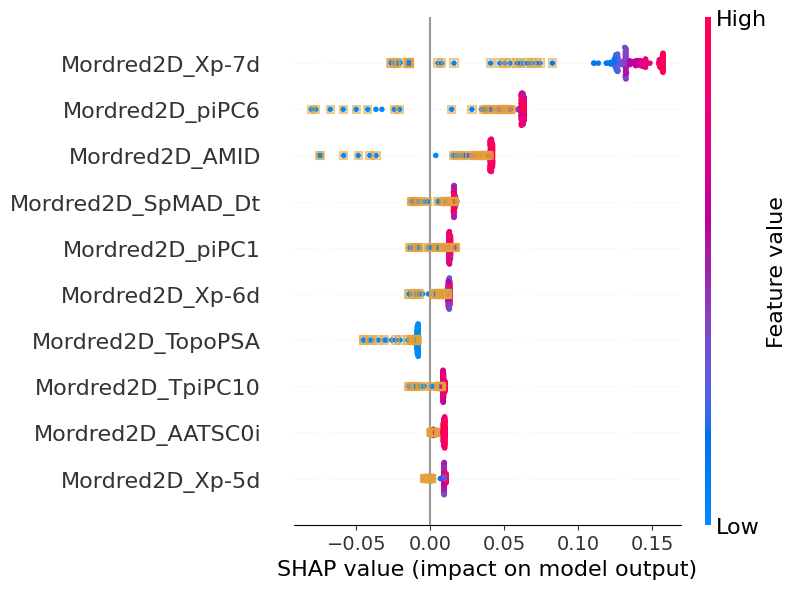

In [ ]:
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
df = pd.read_csv('./homo/TC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Tc-MeanStd.csv')
mean = df_meanstd['mean'].values[:92-11]
std = df_meanstd['std'].values[:92-11]
X_val = df.iloc[:, 2:].astype(np.double).values
X_val = (X_val - mean) / std
feature_names = list(df.columns[2:])
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]
model = joblib.load('../model/rf_tc_2d.pkl')
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
shap.summary_plot(
    shap_values,
    features=X_val,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(8, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=28,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## PC
*   Fig. 9(D)

Explaining the model's predictions using SHAP...


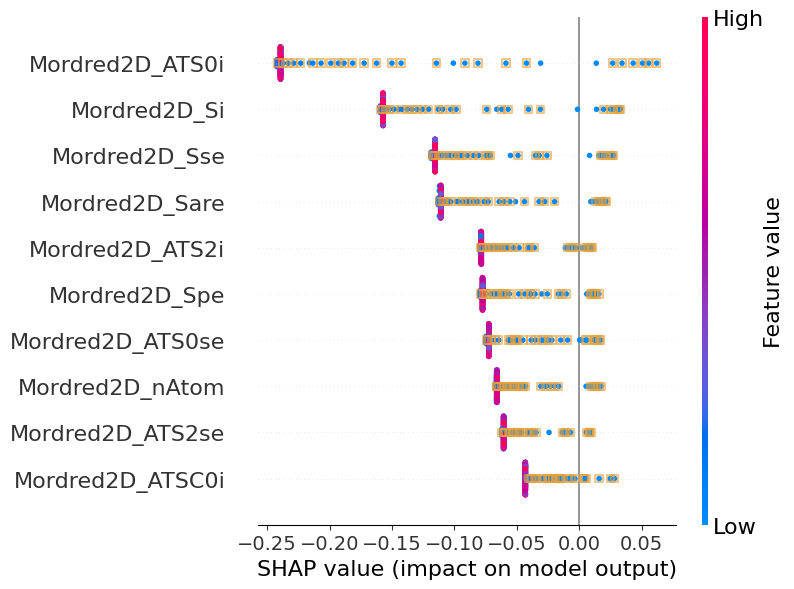

In [ ]:
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
df = pd.read_csv('./homo/PC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Pc-MeanStd.csv')
mean = df_meanstd['mean'].values[:76-11]
std = df_meanstd['std'].values[:76-11]
X_val = df.iloc[:, 2:].astype(np.double).values
X_val = (X_val - mean) / std
feature_names = list(df.columns[2:])
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]
model = joblib.load('../model/rf_pc_2d.pkl')
print("Explaining the model's predictions using SHAP...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
shap.summary_plot(
    shap_values,
    features=X_val,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(8, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=28,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## ANN
*   Fig. 10(C)

Explaining the model's predictions using SHAP...


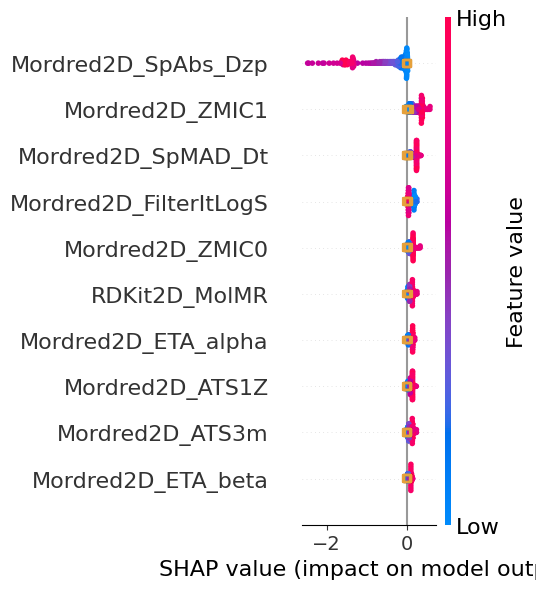

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from model import Crit_model
import shap
import matplotlib.pyplot as plt
torch.set_num_threads(16)
seed_list=[42, 403138084, 573583737, 604087939, 643026125, 661892772, 866264613, 1509598813, 1605674636, 1687343257]
df = pd.read_csv('./homo/TC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Tc-MeanStd.csv')
mean = df_meanstd['mean'].values[:92-11]
std = df_meanstd['std'].values[:92-11]
X_val = df.iloc[:, 2:].astype(np.float32).values
X_val = (X_val - mean) / std
df = pd.read_csv('../database/Crit-Tc.csv')
X_train = df[df['Validation'] == 0].iloc[:, 2:].values
X_train = (X_train - mean) / std
feature_names = list(df.columns[2:])
T_mean = 6.454735946249426 
T_std = 0.22434263421735687
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]

models = []
hidden_dim = 56
hidden_num = 4
hidden_type = "2_2"
activation = "gelu"
dropout = 0.0
for seed in seed_list:
    model = Crit_model(input_size=X_train.shape[1], 
                       output_size=1,
                       hidden_size=hidden_dim, 
                       hidden_num=hidden_num, 
                       hidden_type=hidden_type, 
                       activation=activation, 
                       dropout=dropout)
    model.load_state_dict(torch.load(f'../model/ANN_TC2D_{seed}.pth', weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    models.append(model)

class EnsembleProxyModel(nn.Module):
    def __init__(self, models_list):
        super(EnsembleProxyModel, self).__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        preds = [model(x) for model in self.models]
        stacked_preds = torch.stack(preds, dim=0)
        avg_preds = torch.mean(stacked_preds, dim=0)
        return avg_preds * T_std + T_mean
print("Explaining the model's predictions using SHAP...")
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
ensemble_model = EnsembleProxyModel(models)
ensemble_model.eval()
explainer = shap.explainers.DeepExplainer(ensemble_model, X_train)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
X_val_numpy = X_val.cpu().numpy()
shap.summary_plot(
    shap_values,
    features=X_val_numpy,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(16/3, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=24,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## sANN
*   Fig. 10(D)

Explaining the model's predictions using SHAP...


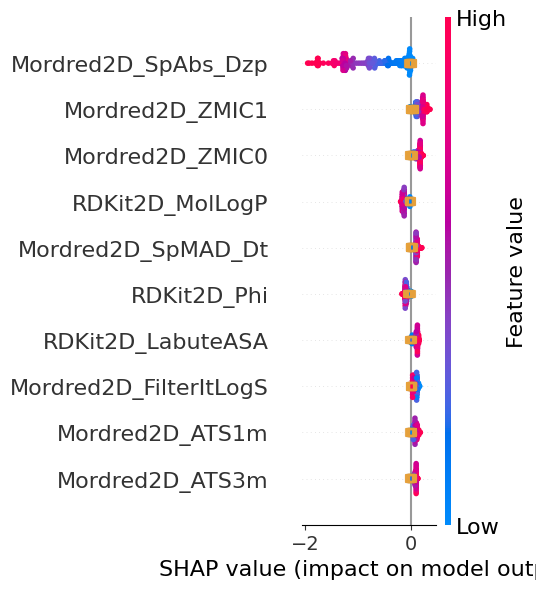

In [ ]:
# TC2D
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from model import Crit_model
import shap
import matplotlib.pyplot as plt
torch.set_num_threads(16)
seed_list=[42, 403138084, 573583737, 604087939, 643026125, 661892772, 866264613, 1509598813, 1605674636, 1687343257]
df = pd.read_csv('./homo/TC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Tc-MeanStd.csv')
mean = df_meanstd['mean'].values[:92-11]
std = df_meanstd['std'].values[:92-11]
X_val = df.iloc[:, 2:].astype(np.float32).values
X_val = (X_val - mean) / std
df = pd.read_csv('../database/Crit-Tc.csv')
X_train = df[df['Validation'] == 0].iloc[:, 2:].values
X_train = (X_train - mean) / std
feature_names = list(df.columns[2:])
T_mean = 6.454735946249426 
T_std = 0.22434263421735687
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]

models = []
hidden_dim = 56
hidden_num = 4
hidden_type = "2_2"
activation = "sigmoid"
dropout = 0.0
for seed in seed_list:
    model = Crit_model(input_size=X_train.shape[1], 
                       output_size=1,
                       hidden_size=hidden_dim, 
                       hidden_num=hidden_num, 
                       hidden_type=hidden_type, 
                       activation=activation, 
                       dropout=dropout)
    model.load_state_dict(torch.load(f'../model/ANN_sTC2D_{seed}.pth', weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    models.append(model)

class EnsembleProxyModel(nn.Module):
    def __init__(self, models_list):
        super(EnsembleProxyModel, self).__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        preds = [model(x) for model in self.models]
        stacked_preds = torch.stack(preds, dim=0)
        avg_preds = torch.mean(stacked_preds, dim=0)
        return avg_preds * T_std + T_mean
print("Explaining the model's predictions using SHAP...")
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
ensemble_model = EnsembleProxyModel(models)
ensemble_model.eval()
explainer = shap.explainers.DeepExplainer(ensemble_model, X_train)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
X_val_numpy = X_val.cpu().numpy()
shap.summary_plot(
    shap_values,
    features=X_val_numpy,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(16/3, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=24,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## dsANN
*   Fig. 10(E)

Explaining the model's predictions using SHAP...


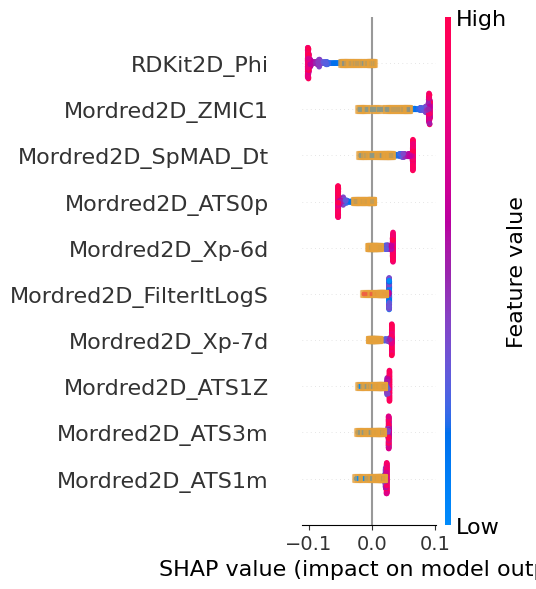

In [6]:
# TC2D
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from model import Crit_model
import shap
import matplotlib.pyplot as plt
torch.set_num_threads(16)
def my_AARD(y_true, y_pred):
    y_true = np.exp(y_true)
    y_pred = np.exp(y_pred)
    aard = np.abs((y_true - y_pred) / y_true) * 100
    return aard
seed_list=[42, 403138084, 573583737, 604087939, 643026125, 661892772, 866264613, 1509598813, 1605674636, 1687343257]
df = pd.read_csv('./homo/TC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Tc-MeanStd.csv')
mean = df_meanstd['mean'].values[:92-11]
std = df_meanstd['std'].values[:92-11]
X_val = df.iloc[:, 2:].astype(np.float32)
X_val = (X_val - mean) / std
df = pd.read_csv('../database/Crit-Tc.csv')
X_train = df[df['Validation'] == 0].iloc[:, 2:].astype(np.float32)
X_train = (X_train - mean) / std
X_train = X_train.drop(columns=['Mordred2D_SpAbs_Dzp']).values
X_val = X_val.drop(columns=['Mordred2D_SpAbs_Dzp']).values
feature_names = list(df.columns[2:])
feature_names = [name for name in feature_names if name != 'Mordred2D_SpAbs_Dzp']
T_mean = 6.454735946249426 
T_std = 0.22434263421735687
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]
        
models = []
hidden_dim = 56
hidden_num = 4
hidden_type = "2_2"
activation = "sigmoid"
dropout = 0.0
for seed in seed_list:
    model = Crit_model(input_size=X_train.shape[1], 
                       output_size=1,
                       hidden_size=hidden_dim, 
                       hidden_num=hidden_num, 
                       hidden_type=hidden_type, 
                       activation=activation, 
                       dropout=dropout)
    model.load_state_dict(torch.load(f'../model/ANN_dsTC2D_{seed}.pth', weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    models.append(model)

class EnsembleProxyModel(nn.Module):
    def __init__(self, models_list):
        super(EnsembleProxyModel, self).__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        preds = [model(x) for model in self.models]
        stacked_preds = torch.stack(preds, dim=0)
        avg_preds = torch.mean(stacked_preds, dim=0)
        return avg_preds * T_std + T_mean
print("Explaining the model's predictions using SHAP...")
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
ensemble_model = EnsembleProxyModel(models)
ensemble_model.eval()
explainer = shap.explainers.DeepExplainer(ensemble_model, X_train)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
X_val_numpy = X_val.cpu().numpy()
shap.summary_plot(
    shap_values,
    features=X_val_numpy,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(16/3, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=24,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## ANN
*   Fig. 10(F)

Explaining the model's predictions using SHAP...


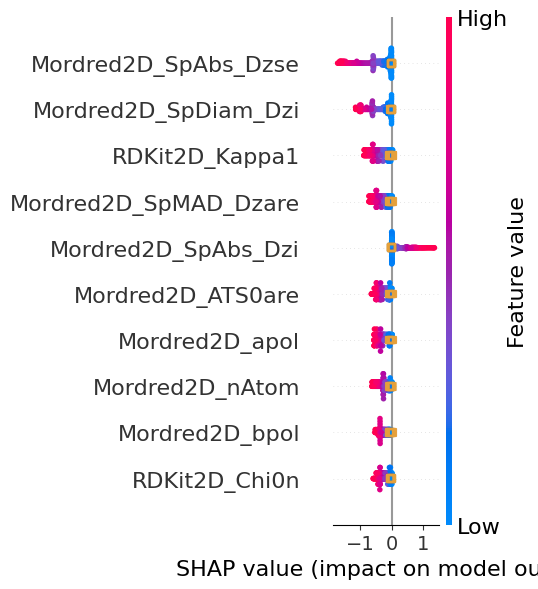

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from model import Crit_model
import shap
import matplotlib.pyplot as plt
torch.set_num_threads(16)
seed_list=[42, 403138084, 573583737, 604087939, 643026125, 661892772, 866264613, 1509598813, 1605674636, 1687343257]
df = pd.read_csv('./homo/PC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Pc-MeanStd.csv')
mean = df_meanstd['mean'].values[:76-11]
std = df_meanstd['std'].values[:76-11]
X_val = df.iloc[:, 2:].astype(np.float32).values
X_val = (X_val - mean) / std
df = pd.read_csv('../database/Crit-Pc.csv')
X_train = df[df['Validation'] == 0].iloc[:, 2:].values
X_train = (X_train - mean) / std
P_mean = 14.989541546234026
P_std = 0.43770555747724915
feature_names = list(df.columns[2:])
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]

models = []
hidden_dim = 44
hidden_num = 2
hidden_type = "1_1"
activation = "gelu"
dropout = 0.0
for seed in seed_list:
    model = Crit_model(input_size=X_val.shape[1], 
                       output_size=1,
                       hidden_size=hidden_dim, 
                       hidden_num=hidden_num, 
                       hidden_type=hidden_type, 
                       activation=activation, 
                       dropout=dropout)
    model.load_state_dict(torch.load(f'../model/ANN_PC2D_{seed}.pth', weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    models.append(model)

class EnsembleProxyModel(nn.Module):
    def __init__(self, models_list):
        super(EnsembleProxyModel, self).__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        preds = [model(x) for model in self.models]
        stacked_preds = torch.stack(preds, dim=0)
        avg_preds = torch.mean(stacked_preds, dim=0)
        return avg_preds * P_std + P_mean
print("Explaining the model's predictions using SHAP...")
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
ensemble_model = EnsembleProxyModel(models)
ensemble_model.eval()
explainer = shap.explainers.DeepExplainer(ensemble_model, X_train)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
X_val_numpy = X_val.cpu().numpy()
shap.summary_plot(
    shap_values,
    features=X_val_numpy,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(16/3, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=24,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## sANN
*   Fig. 10(G)

Explaining the model's predictions using SHAP...


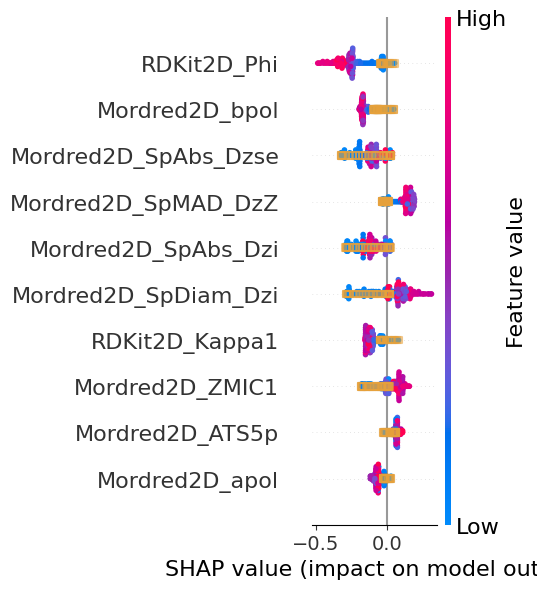

In [ ]:
# PC2D
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from model import Crit_model
import shap
import matplotlib.pyplot as plt
seed_list=[42, 403138084, 573583737, 604087939, 643026125, 661892772, 866264613, 1509598813, 1605674636, 1687343257]
df = pd.read_csv('./homo/PC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Pc-MeanStd.csv')
mean = df_meanstd['mean'].values[:76-11]
std = df_meanstd['std'].values[:76-11]
X_val = df.iloc[:, 2:].astype(np.float32).values
X_val = (X_val - mean) / std
df = pd.read_csv('../database/Crit-Pc.csv')
X_train = df[df['Validation'] == 0].iloc[:, 2:].values
X_train = (X_train - mean) / std
P_mean = 14.989541546234026
P_std = 0.43770555747724915
feature_names = list(df.columns[2:])
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]

models = []
hidden_dim = 44
hidden_num = 2
hidden_type = "1_1"
activation = "sigmoid"
dropout = 0.0
for seed in seed_list:
    model = Crit_model(input_size=X_val.shape[1], 
                       output_size=1,
                       hidden_size=hidden_dim, 
                       hidden_num=hidden_num, 
                       hidden_type=hidden_type, 
                       activation=activation, 
                       dropout=dropout)
    model.load_state_dict(torch.load(f'../model/ANN_sPC2D_{seed}.pth', weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    models.append(model)

class EnsembleProxyModel(nn.Module):
    def __init__(self, models_list):
        super(EnsembleProxyModel, self).__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        preds = [model(x) for model in self.models]
        stacked_preds = torch.stack(preds, dim=0)
        avg_preds = torch.mean(stacked_preds, dim=0)
        return avg_preds * P_std + P_mean
print("Explaining the model's predictions using SHAP...")
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
ensemble_model = EnsembleProxyModel(models)
ensemble_model.eval()
explainer = shap.explainers.DeepExplainer(ensemble_model, X_train)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
X_val_numpy = X_val.cpu().numpy()
shap.summary_plot(
    shap_values,
    features=X_val_numpy,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(16/3, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=24,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

## dsANN
*   Fig. 10(H)

Explaining the model's predictions using SHAP...


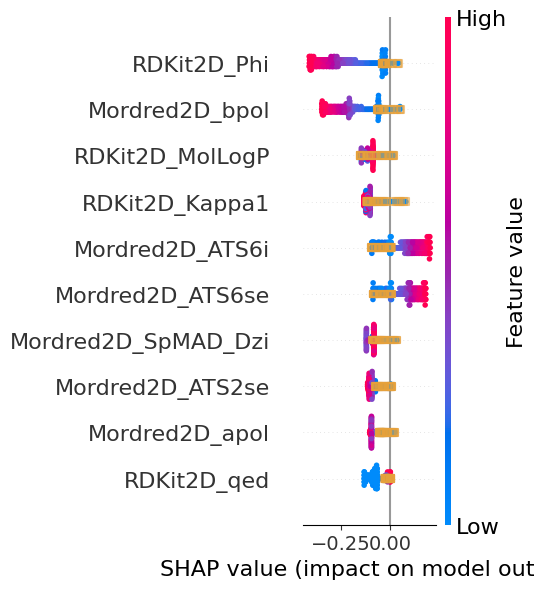

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from model import Crit_model
import shap
import matplotlib.pyplot as plt
seed_list=[42, 403138084, 573583737, 604087939, 643026125, 661892772, 866264613, 1509598813, 1605674636, 1687343257]
df = pd.read_csv('./homo/PC_feature.csv')
df_meanstd = pd.read_csv('../database/Crit-Pc-MeanStd.csv')
mean = df_meanstd['mean'].values[:76-11]
std = df_meanstd['std'].values[:76-11]
X_val = df.iloc[:, 2:].astype(np.float32)
X_val = (X_val - mean) / std
df = pd.read_csv('../database/Crit-Pc.csv')
X_train = df[df['Validation'] == 0].iloc[:, 2:]
X_train = (X_train - mean) / std
spe = ['Mordred2D_SpAbs_Dzse', 'Mordred2D_SpMAD_DzZ', 'Mordred2D_SpAbs_Dzi', 'Mordred2D_SpDiam_Dzi','Mordred2D_ZMIC1' ,'Mordred2D_ATS5p']
X_train = X_train.drop(columns=spe).values
X_val = X_val.drop(columns=spe).values
P_mean = 14.989541546234026
P_std = 0.43770555747724915
feature_names = list(df.columns[2:])
feature_names = [name for name in feature_names if name not in spe]
cluster_mask = [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29]

hidden_dim = 44
hidden_num = 2
hidden_type = "1_1"
activation = "sigmoid"
dropout = 0.0
models = []
for seed in seed_list:
    model = Crit_model(input_size=X_val.shape[1], 
                       output_size=1,
                       hidden_size=hidden_dim, 
                       hidden_num=hidden_num, 
                       hidden_type=hidden_type, 
                       activation=activation, 
                       dropout=dropout)
    model.load_state_dict(torch.load(f'../model/ANN_dsPC2D_{seed}.pth', weights_only=True, map_location=torch.device('cpu')))
    model.eval()
    models.append(model)

class EnsembleProxyModel(nn.Module):
    def __init__(self, models_list):
        super(EnsembleProxyModel, self).__init__()
        self.models = nn.ModuleList(models_list)

    def forward(self, x):
        preds = [model(x) for model in self.models]
        stacked_preds = torch.stack(preds, dim=0)
        avg_preds = torch.mean(stacked_preds, dim=0)
        return avg_preds * P_std + P_mean
print("Explaining the model's predictions using SHAP...")
X_train = torch.from_numpy(X_train).float()
X_val = torch.from_numpy(X_val).float()
ensemble_model = EnsembleProxyModel(models)
ensemble_model.eval()
explainer = shap.explainers.DeepExplainer(ensemble_model, X_train)
shap_values = explainer.shap_values(X_val)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]
X_val_numpy = X_val.cpu().numpy()
shap.summary_plot(
    shap_values,
    features=X_val_numpy,
    feature_names=feature_names,
    max_display=10,
    show=False,
    plot_size=(16/3, 6)
)
ax = plt.gca()
feature_order = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
for plot_y, feature_idx in enumerate(feature_order):
    selected_shap = shap_values[cluster_mask, feature_idx]
    ax.scatter(
        selected_shap,
        np.full(len(selected_shap), plot_y),
        marker='s',
        s=24,
        facecolors='none',
        edgecolors='#e6a13b',
        linewidths=1.5,
        zorder=10,
        alpha=0.6
    )
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=16)
fig = plt.gcf()
cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("Feature value", fontsize=16)
cbar_ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()